
Лабораторная работа 3: Подготовить jupyter-ноутбук с описанием решения. Просьба подробно всё пояснять с комментариями и выводами.

Взять стандартную архитектуру ResNet (например, ResNet18 или ResNet34) Обучить ее на выбранном Вами датасете (например, можете взять датасет со спортивными трансляциями). Учить с нуля не нужно, достаточно потюнить полносвязный слой. Модифицировать encoder ResNet-а, добавив в него механизм Self-Attention Обучить модифицированную архитектуру с Self-Attention на этом же датасете. Сравнить две модели на тестовой выборке из датасета. Параметры тестирования и сиды необходимо закрепить для проведения корректного сравнения. Составить таблицу с результами. Добавить выводы.

# Ход работы

## Загрузка данных

Импорты

In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18

from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, classification_report
import os

Закрепляем всевозможные сиды

In [2]:
def seed_everything(seed: int):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device: {DEVICE}")
SEED = 42
seed_everything(SEED)

Device: cuda


Работать будем с датасетом Oxford-IIIT Pet Dataset по многоклассовой класификации разных пород кошек и собак

Загрузим датасет и приведем данные к нужному нам формату

In [3]:
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import random_split

IMG_SIZE = 224

#  скелер для imagenet по каналам
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]


# для трейна добавим аугментацию
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])

# тестовую выборку оставим без аугментации для корректной оценки
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std)
])


# загрузка датасета
full_dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True,
    transform=train_transform
)

num_classes = len(full_dataset.classes)

print(f"Количество изображений: {len(full_dataset)}")
print(f"Количество классов: {num_classes}")

# разделим и трейн и тест
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

print("\nРазмеры выборок:")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")

print("\nПервые 10 классов:")
print(full_dataset.classes[:10])

Количество изображений: 3680
Количество классов: 37

Размеры выборок:
Train: 2576
Validation: 552
Test: 552

Первые 10 классов:
['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair']


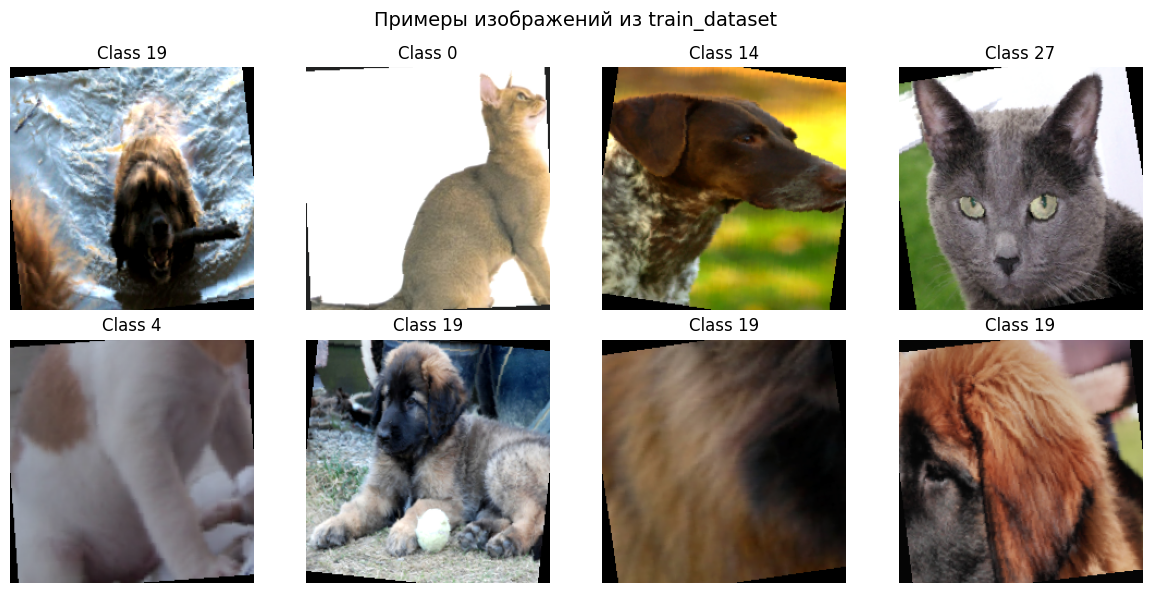

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import torch

mean = torch.tensor(imagenet_mean).view(3, 1, 1)
std = torch.tensor(imagenet_std).view(3, 1, 1)

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i in range(8):

    image, label = train_dataset[i]

    # Денормализуем
    image = image * std + mean

    image = image.permute(1, 2, 0).numpy()

    image = np.clip(image, 0, 1)

    ax = axes[i // 4, i % 4]
    ax.imshow(image)


    ax.set_title(f"Class {label}")

    ax.axis("off")

plt.suptitle("Примеры изображений из train_dataset", fontsize=14)
plt.tight_layout()
plt.show()

Создадим фиксированные даталодеры для корректной проверки на разных архитектурах

In [5]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

## Обучение только полносвязной головы над ResNet

Загрузим предобученную ResNet18

In [6]:
from torchvision.models import resnet18, ResNet18_Weights

weights = ResNet18_Weights.IMAGENET1K_V1

model = resnet18(weights=weights)

print("Предобученная ResNet18 успешно загружена")

Предобученная ResNet18 успешно загружена


Заморозим обучение все слоев, отедльно включим обучение только для новой полносвязной головы

In [7]:
for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(in_features, num_classes)
)


for param in model.fc.parameters():
    param.requires_grad = True

Перенесем модель на gpu и проверим архитектуру выводом всех слоев и проверкой кол-ва обучаемых параметров

In [8]:
model = model.to(DEVICE)

print(model.fc)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nВсего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")
print(
    f"Доля обучаемых параметров: "
    f"{100 * trainable_params / total_params:.2f}%"
)

images, labels = next(iter(train_loader))

images = images.to(DEVICE)

with torch.no_grad():
    outputs = model(images)

Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=37, bias=True)
)

Всего параметров: 11,195,493
Обучаемых параметров: 18,981
Доля обучаемых параметров: 0.17%


Видим, что все корректно и обучаемых параметров мало

Обучим полносвязную голову над ResNet

In [9]:
from copy import deepcopy
from tqdm import tqdm
import torch.optim as optim

NUM_EPOCHS = 10
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE
)


# функция обучения эпохи
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    # прогоняем полный цикл для каждого батча
    for images, labels in tqdm(dataloader, leave=False):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# отлючим хранение промежуточных вычислений для необучаемых слоев, чтобы не задействовать лишнюю память
@torch.no_grad()

# функция для подсчетов на валидационной выборке
def validate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in dataloader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc



# цикл обучения по эпохам
history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_weights = deepcopy(model.state_dict())

for epoch in range(NUM_EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_weights = deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )


# загружаем лучшую модель
model.load_state_dict(best_model_weights)

print("\nОбучение завершено.")
print(f"Лучшая Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/10] | Train Loss: 2.8911 | Train Acc: 0.2527 | Val Loss: 1.9055 | Val Acc: 0.6069


Epoch [2/10] | Train Loss: 1.7731 | Train Acc: 0.5532 | Val Loss: 1.4152 | Val Acc: 0.6685


Epoch [3/10] | Train Loss: 1.3919 | Train Acc: 0.6332 | Val Loss: 1.1417 | Val Acc: 0.7246


Epoch [4/10] | Train Loss: 1.1972 | Train Acc: 0.6891 | Val Loss: 1.0070 | Val Acc: 0.7283


Epoch [5/10] | Train Loss: 1.0596 | Train Acc: 0.7155 | Val Loss: 0.9553 | Val Acc: 0.7373


Epoch [6/10] | Train Loss: 1.0384 | Train Acc: 0.7108 | Val Loss: 0.9021 | Val Acc: 0.7464


Epoch [7/10] | Train Loss: 0.9645 | Train Acc: 0.7341 | Val Loss: 0.8551 | Val Acc: 0.7518


Epoch [8/10] | Train Loss: 0.9611 | Train Acc: 0.7275 | Val Loss: 0.8357 | Val Acc: 0.7572


Epoch [9/10] | Train Loss: 0.9047 | Train Acc: 0.7411 | Val Loss: 0.8170 | Val Acc: 0.7391


Epoch [10/10] | Train Loss: 0.9034 | Train Acc: 0.7372 | Val Loss: 0.7739 | Val Acc: 0.7717

Обучение завершено.
Лучшая Validation Accuracy: 0.7717


Оценим качество полученной модели на тестовой выборке:

In [10]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(DEVICE)

        outputs = model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())


test_accuracy = accuracy_score(all_labels, all_preds)

test_precision = precision_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    all_labels,
    all_preds,
    average="weighted",
    zero_division=0
)


baseline_results = {
    "Model": "ResNet18",
    "Accuracy": test_accuracy,
    "Precision": test_precision,
    "Recall": test_recall,
    "F1-score": test_f1
}


print("=" * 50)
print("Результаты базовой ResNet18")
print("=" * 50)

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-score : {test_f1:.4f}")

100%|██████████| 18/18 [00:03<00:00,  4.53it/s]

Результаты базовой ResNet18
Accuracy : 0.7627
Precision: 0.7927
Recall   : 0.7627
F1-score : 0.7654


Видим итоговую точность в 76%

## Обучение Self-Attention + полновсвязная голова

Создадим класс слоя Self-Attention для последующего добавления в модель

In [11]:
import torch
import torch.nn as nn

class SelfAttention(nn.Module):

    # инициализация
    def __init__(self, in_channels):

        super().__init__()

        self.query_conv = nn.Conv2d(
            in_channels,
            in_channels // 8,
            kernel_size=1
        )

        self.key_conv = nn.Conv2d(
            in_channels,
            in_channels // 8,
            kernel_size=1
        )

        self.value_conv = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=1
        )

        self.softmax = nn.Softmax(dim=-1)

        self.gamma = nn.Parameter(torch.zeros(1))

    # прямой шаг по слою
    def forward(self, x):

        batch_size, channels, height, width = x.size()

        query = self.query_conv(x)

        query = query.view(
            batch_size,
            -1,
            height * width
        ).permute(0, 2, 1)


        key = self.key_conv(x)

        key = key.view(
            batch_size,
            -1,
            height * width
        )

        # строим attention map

        attention = torch.bmm(query, key)

        attention = self.softmax(attention)

        value = self.value_conv(x)

        value = value.view(
            batch_size,
            channels,
            height * width
        )

        #Взвешивание признаков
        out = torch.bmm(
            value,
            attention.permute(0, 2, 1)
        )

        out = out.view(
            batch_size,
            channels,
            height,
            width
        )

        out = self.gamma * out + x

        return out



# проверим работостпособность блока
attention_block = SelfAttention(512).to(DEVICE)

dummy_input = torch.randn(
    2,
    512,
    7,
    7
).to(DEVICE)

dummy_output = attention_block(dummy_input)

print("Input shape :", dummy_input.shape)
print("Output shape:", dummy_output.shape)

assert dummy_input.shape == dummy_output.shape

Input shape : torch.Size([2, 512, 7, 7])
Output shape: torch.Size([2, 512, 7, 7])


Модифицируем ResNet, добавив self-attention блок и полносвязную голову

In [12]:
from torchvision.models import resnet18, ResNet18_Weights
import torch.nn as nn

class ResNet18WithAttention(nn.Module):

    def __init__(self, num_classes):

        super().__init__()


        #Предобученная ResNet
        backbone = resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1
        )

        #
        # фиксируем encoder ResNet18
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # добавляем Self-Attention и полносвязную голову после layer4

        self.attention = SelfAttention(
            in_channels=512
        )

        self.avgpool = backbone.avgpool

        self.fc = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )
    # прописываем прямой шаг
    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.attention(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

Создадим полученную модель

In [13]:
attention_model = ResNet18WithAttention(
    num_classes=num_classes
)

#замораживаем все слои кроме нужных
for param in attention_model.parameters():
    param.requires_grad = False

for param in attention_model.attention.parameters():
    param.requires_grad = True

for param in attention_model.fc.parameters():
    param.requires_grad = True

Проверим, что все правильно зафиксировали

In [14]:
attention_model = attention_model.to(DEVICE)

print(attention_model)

total_params = sum(
    p.numel()
    for p in attention_model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in attention_model.parameters()
    if p.requires_grad
)

print("\n" + "=" * 50)
print("ResNet18 + Self-Attention")
print("=" * 50)

print(f"Всего параметров: {total_params:,}")
print(f"Обучаемых параметров: {trainable_params:,}")

ResNet18WithAttention(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(i

Обучим полученную модель

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim

from copy import deepcopy

NUM_EPOCHS = 8
LEARNING_RATE = 1e-3

criterion = nn.CrossEntropyLoss()

optimizer_attention = optim.Adam(
    filter(
        lambda p: p.requires_grad,
        attention_model.parameters()
    ),
    lr=LEARNING_RATE
)


attention_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_attention_acc = 0.0
best_attention_weights = deepcopy(
    attention_model.state_dict()
)

# обучение стандартным циклом по эпохам
for epoch in range(NUM_EPOCHS):
    attention_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{NUM_EPOCHS}",
        leave=False
    ):

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_attention.zero_grad()

        outputs = attention_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_attention.step()

        train_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # валидация
    attention_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = attention_model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)

            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    attention_history["train_loss"].append(
        epoch_train_loss
    )

    attention_history["train_acc"].append(
        epoch_train_acc
    )

    attention_history["val_loss"].append(
        epoch_val_loss
    )

    attention_history["val_acc"].append(
        epoch_val_acc
    )

    # Сохраняем лучшую модель
    if epoch_val_acc > best_attention_acc:

        best_attention_acc = epoch_val_acc

        best_attention_weights = deepcopy(
            attention_model.state_dict()
        )

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_acc:.4f} | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_acc:.4f}"
    )

#оставляем лучшую модель
attention_model.load_state_dict(
    best_attention_weights
)

print("\nОбучение завершено.")
print(
    f"Лучшая Validation Accuracy: "
    f"{best_attention_acc:.4f}"
)

Epoch [1/8] | Train Loss: 2.5707 | Train Acc: 0.3230 | Val Loss: 1.2770 | Val Acc: 0.6612


Epoch [2/8] | Train Loss: 1.1177 | Train Acc: 0.6793 | Val Loss: 0.9724 | Val Acc: 0.7065


Epoch [3/8] | Train Loss: 0.9207 | Train Acc: 0.7205 | Val Loss: 0.9250 | Val Acc: 0.7210


Epoch [4/8] | Train Loss: 0.8808 | Train Acc: 0.7302 | Val Loss: 0.8050 | Val Acc: 0.7591


Epoch [5/8] | Train Loss: 0.8373 | Train Acc: 0.7438 | Val Loss: 0.8520 | Val Acc: 0.7210


Epoch [6/8] | Train Loss: 0.8373 | Train Acc: 0.7512 | Val Loss: 0.8747 | Val Acc: 0.7228


Epoch [7/8] | Train Loss: 0.8093 | Train Acc: 0.7531 | Val Loss: 0.7972 | Val Acc: 0.7627


Epoch [8/8] | Train Loss: 0.7877 | Train Acc: 0.7531 | Val Loss: 0.7591 | Val Acc: 0.7790

Обучение завершено.
Лучшая Validation Accuracy: 0.7790


Проверим точность на тестовой выборке:

In [16]:
attention_model.eval()

all_preds_att = []
all_labels_att = []

# получаем предикт
with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing Attention Model"
    ):

        images = images.to(DEVICE)

        outputs = attention_model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds_att.extend(
            preds.cpu().numpy()
        )

        all_labels_att.extend(
            labels.numpy()
        )


attention_accuracy = accuracy_score(
    all_labels_att,
    all_preds_att
)

attention_precision = precision_score(
    all_labels_att,
    all_preds_att,
    average="weighted",
    zero_division=0
)

attention_recall = recall_score(
    all_labels_att,
    all_preds_att,
    average="weighted",
    zero_division=0
)

attention_f1 = f1_score(
    all_labels_att,
    all_preds_att,
    average="weighted",
    zero_division=0
)

attention_results = {
    "Model": "ResNet18 + Self-Attention",
    "Accuracy": attention_accuracy,
    "Precision": attention_precision,
    "Recall": attention_recall,
    "F1-score": attention_f1
}

print("=" * 60)
print("Результаты ResNet18 + Self-Attention")
print("=" * 60)

print(f"Accuracy : {attention_accuracy:.4f}")
print(f"Precision: {attention_precision:.4f}")
print(f"Recall   : {attention_recall:.4f}")
print(f"F1-score : {attention_f1:.4f}")

Testing Attention Model: 100%|██████████| 18/18 [00:05<00:00,  3.42it/s]

Результаты ResNet18 + Self-Attention
Accuracy : 0.7554
Precision: 0.7736
Recall   : 0.7554
F1-score : 0.7531


Видим, что точность ухудшилась на 1%, и лосс перестал падать на последних эпохах, что означает, что проблема в архитектуре, а не недобучении.

## Частичное обучение encoder и self-attention

Гипотеза: возможно self-attention появлется слишком поздно и не способен уловить нужные участки на слишком очищенных примитивах после слоев.

Поэтому попробуем добавит self-attention блок перед layer3 и зафайнтюнить веса на layer3 и layer4.

ПРобовал сделать также, но только с layer4, но улучшений не дало, поэтому взял два предыдущих уровня

Модифицируем ResNet, добавив self-attention блок после layer2 и полносвязную голову после layer4

In [17]:
from torchvision.models import resnet18, ResNet18_Weights
import torch
import torch.nn as nn
import torch.optim as optim

class ResNet18WithAttentionV2(nn.Module):

    def __init__(self, num_classes):

        super().__init__()
        #Предобученная ResNet
        backbone = resnet18(
            weights=ResNet18_Weights.IMAGENET1K_V1
        )

        # фиксируем encoder ResNet18
        self.conv1 = backbone.conv1
        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool

        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        # добавляем Self-Attention и полносвязную голову
        self.attention = SelfAttention(
            in_channels=128
        )

        self.avgpool = backbone.avgpool

        self.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(512, num_classes)
        )

    # прописываем прямой шаг
    def forward(self, x):

        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)

        x = self.layer2(x)

        # Self-Attention
        x = self.attention(x)

        x = self.layer3(x)

        x = self.layer4(x)

        x = self.avgpool(x)

        x = torch.flatten(x, 1)

        x = self.fc(x)

        return x

Создадим полученную модель

In [18]:
attention_model = ResNet18WithAttentionV2(
    num_classes=num_classes
)

#замораживаем все слои кроме нужных
for param in attention_model.parameters():
    param.requires_grad = False



for param in attention_model.layer3.parameters():
    param.requires_grad = True

for param in attention_model.layer4.parameters():
    param.requires_grad = True

for param in attention_model.attention.parameters():
    param.requires_grad = True

for param in attention_model.fc.parameters():
    param.requires_grad = True

Проверим, что все правильно зафиксировали

In [19]:
attention_model = attention_model.to(DEVICE)

trainable_params = sum(
    p.numel()
    for p in attention_model.parameters()
    if p.requires_grad
)

print(f"Обучаемых параметров: {trainable_params:,}")

Обучаемых параметров: 10,533,062


Кол-во обучаемых параметров сильно выросло

Настроим полученную модель

In [20]:
criterion = nn.CrossEntropyLoss()

# настроим спуск так, чтобы уже обученные веса в layer3 и layer4 обучались медленее
optimizer_attention = optim.Adam(

    [
        {
            "params": attention_model.layer3.parameters(),
            "lr": 1e-5
        },

        {
            "params": attention_model.layer4.parameters(),
            "lr": 1e-5
        },

        {
            "params": attention_model.attention.parameters(),
            "lr": 1e-3
        },

        {
            "params": attention_model.fc.parameters(),
            "lr": 1e-3
        }
    ],

    weight_decay=1e-4
)


scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_attention,
    mode="max",
    factor=0.5,
    patience=2
)

#увеличим кол-во эпох, т.к. кол-во обучаемых параметров сильно выросло
NUM_EPOCHS = 20

Обучим полученную модель

In [21]:
attention_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_attention_acc = 0.0
best_attention_weights = deepcopy(
    attention_model.state_dict()
)


# обучение стандартным циклом по эпохам
for epoch in range(NUM_EPOCHS):
    attention_model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(
        train_loader,
        desc=f"Epoch {epoch + 1}/{NUM_EPOCHS}",
        leave=False
    )

    for images, labels in train_bar:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer_attention.zero_grad()

        outputs = attention_model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer_attention.step()

        train_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)

        train_correct += (
            preds == labels
        ).sum().item()

        train_total += labels.size(0)

        train_bar.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total

    # валидация
    attention_model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            outputs = attention_model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += (
                loss.item() * images.size(0)
            )

            preds = outputs.argmax(dim=1)

            val_correct += (
                preds == labels
            ).sum().item()

            val_total += labels.size(0)

    epoch_val_loss = val_loss / val_total
    epoch_val_acc = val_correct / val_total

    scheduler.step(epoch_val_acc)

    attention_history["train_loss"].append(
        epoch_train_loss
    )

    attention_history["train_acc"].append(
        epoch_train_acc
    )

    attention_history["val_loss"].append(
        epoch_val_loss
    )

    attention_history["val_acc"].append(
        epoch_val_acc
    )

    # Сохраняем лучшую модель
    if epoch_val_acc > best_attention_acc:

        best_attention_acc = epoch_val_acc

        best_attention_weights = deepcopy(
            attention_model.state_dict()
        )

    current_lr = optimizer_attention.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | "
        f"LR={current_lr:.6f} | "
        f"Train Loss={epoch_train_loss:.4f} | "
        f"Train Acc={epoch_train_acc:.4f} | "
        f"Val Loss={epoch_val_loss:.4f} | "
        f"Val Acc={epoch_val_acc:.4f}"
    )

#оставляем лучшую модель
attention_model.load_state_dict(
    best_attention_weights
)

print("\n" + "=" * 60)
print("Обучение завершено")
print("=" * 60)
print(
    f"Best Validation Accuracy: "
    f"{best_attention_acc:.4f}"
)

torch.save(
    attention_model.state_dict(),
    "best_attention_model.pth"
)

print(
    "Веса сохранены в "
    "'best_attention_model.pth'"
)

Epoch [01/20] | LR=0.000010 | Train Loss=2.8798 | Train Acc=0.2500 | Val Loss=1.7974 | Val Acc=0.5707


Epoch [02/20] | LR=0.000010 | Train Loss=1.5800 | Train Acc=0.5850 | Val Loss=1.1558 | Val Acc=0.6866


Epoch [03/20] | LR=0.000010 | Train Loss=1.1781 | Train Acc=0.6755 | Val Loss=0.9221 | Val Acc=0.7373


Epoch [04/20] | LR=0.000010 | Train Loss=0.9583 | Train Acc=0.7329 | Val Loss=0.8571 | Val Acc=0.7428


Epoch [05/20] | LR=0.000010 | Train Loss=0.8312 | Train Acc=0.7628 | Val Loss=0.6890 | Val Acc=0.7935


...

Epoch [16/20] | LR=0.000005 | Train Loss=0.5103 | Train Acc=0.8482 | Val Loss=0.5292 | Val Acc=0.8279


Epoch [17/20] | LR=0.000003 | Train Loss=0.5230 | Train Acc=0.8408 | Val Loss=0.5779 | Val Acc=0.8098


Epoch [18/20] | LR=0.000003 | Train Loss=0.5334 | Train Acc=0.8362 | Val Loss=0.5353 | Val Acc=0.8243


Epoch [19/20] | LR=0.000003 | Train Loss=0.5317 | Train Acc=0.8346 | Val Loss=0.6117 | Val Acc=0.8062


Epoch [20/20] | LR=0.000001 | Train Loss=0.4949 | Train Acc=0.8478 | Val Loss=0.5441 | Val Acc=0.8170

Обучение завершено
Best Validation Accuracy: 0.8333
Веса сохранены в 'best_attention_model.pth'


Проверим точность на тестовой выборке:

In [22]:
attention_model.eval()

all_preds_att = []
all_labels_att = []

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing Attention Model"
    ):

        images = images.to(DEVICE)

        outputs = attention_model(images)

        preds = torch.argmax(outputs, dim=1)

        all_preds_att.extend(
            preds.cpu().numpy()
        )

        all_labels_att.extend(
            labels.numpy()
        )


attention_accuracy = accuracy_score(
    all_labels_att,
    all_preds_att
)

attention_precision = precision_score(
    all_labels_att,
    all_preds_att,
    average="weighted",
    zero_division=0
)

attention_recall = recall_score(
    all_labels_att,
    all_preds_att,
    average="weighted",
    zero_division=0
)

attention_f1 = f1_score(
    all_labels_att,
    all_preds_att,
    average="weighted",
    zero_division=0
)

attention_results = {
    "Model": "ResNet18 + Self-Attention",
    "Accuracy": attention_accuracy,
    "Precision": attention_precision,
    "Recall": attention_recall,
    "F1-score": attention_f1
}

# ============================================
# Вывод результатов
# ============================================

print("=" * 60)
print("Результаты ResNet18 + Self-Attention")
print("=" * 60)

print(f"Accuracy : {attention_accuracy:.4f}")
print(f"Precision: {attention_precision:.4f}")
print(f"Recall   : {attention_recall:.4f}")
print(f"F1-score : {attention_f1:.4f}")

Testing Attention Model: 100%|██████████| 18/18 [00:04<00:00,  4.25it/s]

Результаты ResNet18 + Self-Attention
Accuracy : 0.7772
Precision: 0.7873
Recall   : 0.7772
F1-score : 0.7734


Видим, что точность выросла по српавнению как с просто добавлением полносвязной головы, так и по сравнению с предыдущим варантом self-attention.

Это означает, что на этом уровне слой self-attention способен улавливать нужные примитивы и "подсвечивать" их, что помогло улучшить качество работы модели.

# Вывод

В ходе лабораторной работы были рассмотрены реализации файн-тюнинга в разных вариациях:

* Только полносвязной головы (acc = 0.76)
* Self-Attention блока и полносвязной головы (acc = 0.75)
* Self-Attention блока поставленного перед уже обученными слоями и полносвязной головы (acc = 0.77)

Просто добавление self-Attention блока улучшения не дало и даже немного ухудшило работу модели. Однако добавление Self-Attention блока перед несколькими уже обученными слоями дало улучшение качества.

Главная гипотеза, почему так произошло: Self-Attention блок был бесполезен на позднем этапе обучения, т.к. был не способен работать с настолько низкоуровнеными примитивами. А как только его вынесли вперед, то начал улавливать и подсвечивать нужные закономерности.